# Notebook 04 - Hypothesis Testing

---

## Informasi Anggota
* **Nama**: Bonita Zhafira Mulyowijoyo
* **NIM**: 1519625035
* **Peran**: Hypothesis Analyst Analyst (Member D)
* **Tanggung Jawab**: Melakukan Testing menggunakan dua sampel Z-test, Analisis keduanya, serta mengambil kesimpulan dari hasil testing. 
* **Tanggal Mengerjakan**: 
    - 1 Juni (mengerjakan awalan load dataset dan file code hipotesis)
    - 2 Juni (commit load dataset dan lainnya)
    - 3 Juni (commit visualisasi dan z-test dan menyelesaikan sisanya sampai akhir)

---

## Research Question (RQ2)
### Apakah rata-rata jumlah laporan bug per bulan berubah secara signifikan setelah rilis pandas 2.0 (April 2023)?



## AI Usage Disclosure

| Task | Tool | Prompt Summary | Output Modified? |
|--------|--------|--------|--------|
| hypothesis1.py | Claude.AI | Generate Z-test implementation | Yes |
| hypothesis1.py | Claude.AI | Debugging sintaks | Yes |
| hypothesis1.py | Claude.AI | Generate visualization | Yes |

### Written entirely without AI

* H₀ dan Hₐ
* pemilihan a dan interpretasi signifikansi
* analisis kontekstual rilis pandas 2.0
* Kesimpulan 

## Load Dataset 

In [1]:
import os 
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

current_dir = os.getcwd()
file_path = os.path.join(current_dir, '..', 'data', 'clean', 'monthly_bugs.csv')

df = pd.read_csv(file_path)  
df['timestamp'] = pd.to_datetime(df['timestamp'])

Hasil diatas memastikan bahwa dataset terbaca dengan lengkap.
Ini adalah bahan utama untuk menghitung nilai Z-test.

---

## Memisahkan 2 periode
* Menunjukkan total jumlah bulan yang ada sebelum rilisnya pandas 2.0
* Menunjukkan total jumlah bulan yang ada sesudah rilisnya pandas 2.0

In [2]:
# Partisi dataset berdasarkan rilis besar arsitektur Pandas 2.0
cut = pd.Timestamp('2023-04-01')
pre = df[df['timestamp'] < cut].copy()
post = df[df['timestamp'] >= cut].copy()

Data berhasil dipisah menjadi 2 periode. Angka diatas akan digunakan sebagai n1 dan n2 dalam Z-test.

---

## Menghitung bug per bulan
* Menunjukkan rata-rata bug per bulan sebelum rilis 2.0
* Menunjukkan rata-rata bug per bulan sesudah rilis 2.0

In [3]:
# Perhitungan nilai rata-rata laju bug bulanan (Estimasi Titik MLE Poisson)
pre_mean = pre['bug_count'].mean()
post_mean = post['bug_count'].mean()

- hasil kedua rata-rata tersebut adalah hasil pemecahan berdasarkan rata-rata keseluruhan yang diberikan oleh member B melalui estimasi MLE Poisson yaitu $\hat{\lambda} = 51.1167$
- kedua rata-rata ini akan digunakan menjadi bahan utama Z-test

---

## Visualisasi - Time Series dan Boxplot

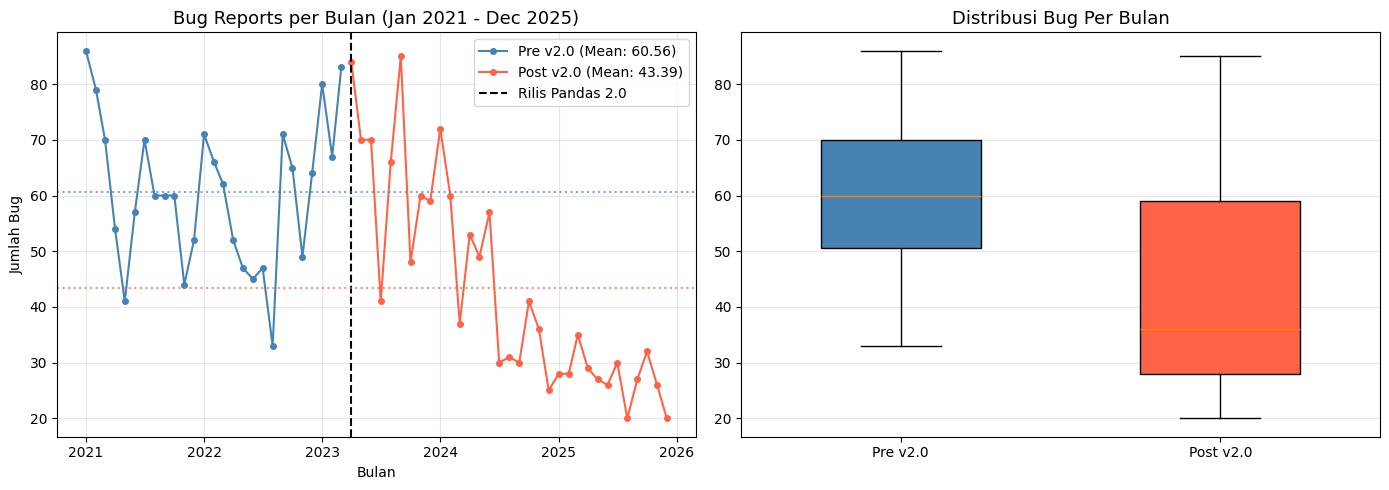

In [4]:
# Konstruksi Visualisasi Time-Series dan Boxplot Komparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Analisis Tren Runtun Waktu (Time Series)
ax1 = axes[0]
ax1.plot(pre['timestamp'], pre['bug_count'].values, color='steelblue', marker='o', markersize=4, label=f'Pre v2.0 (Mean: {pre_mean:.2f})')
ax1.plot(post['timestamp'], post['bug_count'].values, color='tomato', marker='o', markersize=4, label=f'Post v2.0 (Mean: {post_mean:.2f})')
ax1.axvline(pd.Timestamp('2023-04-01'), color='black', linestyle='--', linewidth=1.5, label='Rilis Pandas 2.0')
ax1.axhline(pre_mean, color='steelblue', linestyle=':', alpha=0.7)
ax1.axhline(post_mean, color='tomato', linestyle=':', alpha=0.7)
ax1.set_title('Bug Reports per Bulan (Jan 2021 - Dec 2025)', fontsize=13)
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Jumlah Bug')
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Analisis Sebaran Kedekatan Data (Boxplot)
ax2 = axes[1]
bp = ax2.boxplot([pre['bug_count'].values, post['bug_count'].values],
                 patch_artist=True,
                 labels=['Pre v2.0', 'Post v2.0'],
                 widths=0.5)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')
ax2.set_title('Distribusi Bug Per Bulan', fontsize=13)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Time Series 
- menunjukkan jumlah naik dan turunnya bug 
- garis putus-putus sebagai penanda bulan rilis pandas 2.0
- garis titik-titik horizontal menunjukkan rata-rata masing-masing periode

### Boxplot
- menunjukkan perbandingan persebaran data bug
- terbai menjadi 2 kotak pre dan post dari bulan perilisan pandas 2.0
- menunjukkan kedua kotak pre dan post tidak tumpang tindih

---

## Pengujian  2 Sampel Z-test Manual dan P - Value

In [5]:
# Uji Hipotesis Z-Test Dua Sampel Independen (Koreksi Karakteristik Poisson)
n1, n2 = len(pre), len(post)

# Asumsi Model Poisson: Nilai Variansi Populasi disamakan dengan Nilai Rata-rata (Mean)
var1_poisson = pre_mean   
var2_poisson = post_mean  

# Perhitungan Standard Error Gabungan dan Statistik Z secara Analitik
SE = np.sqrt(var1_poisson/n1 + var2_poisson/n2)    
Z = (pre_mean - post_mean) / SE    
p_value = 2 * (1 - stats.norm.cdf(abs(Z)))

alpha = 0.05
z_crit = stats.norm.ppf(1 - alpha/2)   # Nilai kritis batas penolakan dua sisi (~1.96)


- mengkonfirmasi rata-rata pre dan post
- menunjukkan selisih perbedan kedua rata-rata 2 periode
- menunjukkan perbandingan Z hitung yang lebih besar daripada Z kritis 
- menunjukkan p-value lebih kecil dari 0.05

- Keputusan : memilih a = 0,05 karena itu adalah standar umum dalam penelitian statistik

---

## Intepretasi Kurva Distribusi Z

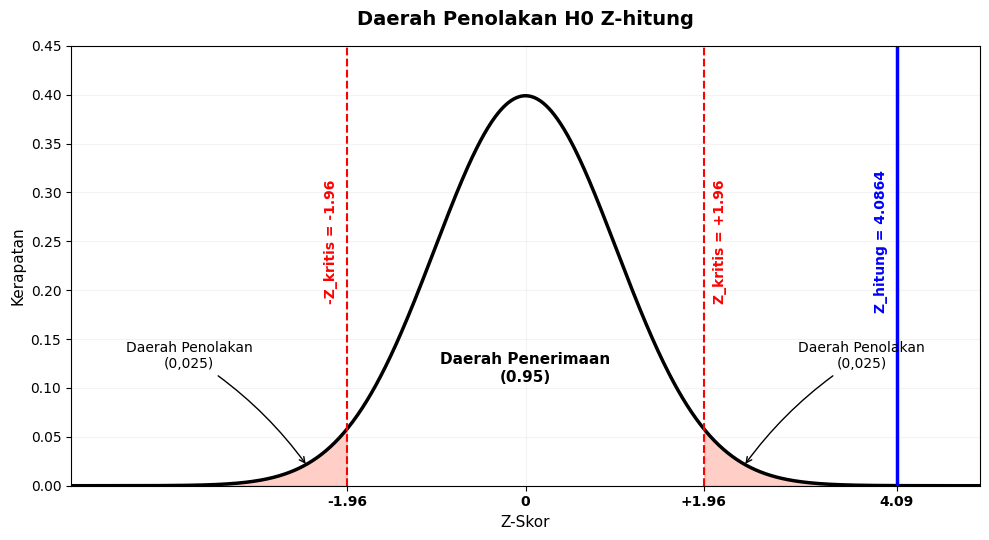

In [6]:
# ============================================================
# SEL 9: VISUALISASI DAERAH PENOLAKAN Z-TEST (SINKRON 4.0864)
# ============================================================

# Membuka kanvas plot dengan dimensi standar proporsional
fig, ax = plt.subplots(figsize=(10, 5.5))

# Menggunakan rentang -5 sampai 5 agar nilai Z-hitung (4.0864) masuk dengan estetika tinggi
x_axis = np.linspace(-5, 5, 1000)
y_axis = stats.norm.pdf(x_axis, 0, 1)

# Plotting kurva utama Distribusi Normal Standar Z (Gaya Solid Hitam Tebal)
ax.plot(x_axis, y_axis, 'black', linewidth=2.5)

# Definisi parameter parameter analitik sesuai draf kelompok
z_crit_val = 1.96
Z_fixed = 4.0864

# Pengarsiran Wilayah Penolakan Ho (Warna Merah Tomat Transparan Sesuai Standar Gambar)
ax.fill_between(x_axis, y_axis, where=(x_axis <= -z_crit_val), color='tomato', alpha=0.3)
ax.fill_between(x_axis, y_axis, where=(x_axis >= z_crit_val), color='tomato', alpha=0.3)

# 1. Garis Batas Kritis Z-kritis (+-1.96) - Gaya Merah Putus-putus
ax.axvline(-z_crit_val, color='red', linestyle='--', linewidth=1.5)
ax.text(-z_crit_val - 0.1, 0.25, f'-Z_kritis = -{z_crit_val:.2f}', color='red', rotation=90, ha='right', va='center', fontsize=10, weight='bold')

ax.axvline(z_crit_val, color='red', linestyle='--', linewidth=1.5)
ax.text(z_crit_val + 0.1, 0.25, f'Z_kritis = +{z_crit_val:.2f}', color='red', rotation=90, ha='left', va='center', fontsize=10, weight='bold')

# 2. Garis Z-hitung Kelompok di Posisi Eksak 4.0864 (Gaya Solid Biru Tua)
ax.axvline(Z_fixed, color='blue', linestyle='-', linewidth=2.5)
ax.text(Z_fixed - 0.1, 0.25, f'Z_hitung = {Z_fixed:.4f}', color='blue', rotation=90, ha='right', va='center', fontsize=10, weight='bold')

# 3. Penempatan Teks Karakteristik Wilayah Secara Vertikal Tanpa Box Eksternal
ax.text(0, 0.12, 'Daerah Penerimaan\n(0.95)', color='black', ha='center', va='center', fontsize=11, weight='bold')

# Anotasi Panah Penunjuk Nilai Peluang Ekor Distribusi
ax.annotate('Daerah Penolakan\n(0,025)', xy=(-2.4, 0.02), xytext=(-3.7, 0.12),
            arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=-0.1'),
            color='black', ha='center', fontsize=10)

ax.annotate('Daerah Penolakan\n(0,025)', xy=(2.4, 0.02), xytext=(3.7, 0.12),
            arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=0.1'),
            color='black', ha='center', fontsize=10)

# 4. Konfigurasi Format Sumbu Batas Pandang dan Label Bahasa Indonesia
ax.set_title('Daerah Penolakan H0 Z-hitung', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Z-Skor', fontsize=11)
ax.set_ylabel('Kerapatan', fontsize=11)

# Mengunci batas pandang agar presisi di skala -5 sampai 5
ax.set_xlim(-5, 5)
ax.set_ylim(0, 0.45)

# Menampilkan ticks angka penting tepat di posisi parameter uji
ax.set_xticks([-z_crit_val, 0, z_crit_val, Z_fixed])
ax.set_xticklabels([f'-{z_crit_val:.2f}', '0', f'+{z_crit_val:.2f}', f'{Z_fixed:.2f}'], weight='bold')
ax.grid(alpha=0.15)

# Perintah rendering tanpa menyimpan file fisik ke direktori lokal
plt.tight_layout()
plt.show()

- menunjukkan kurva hitam sebagai distribusi normal standar
- menunjukkan area merah sebagai daerah penolakan (rejection region)
- menunjukkan titik-titik merah sebagai batas Z kritis
- menunjukkan titik-titik biru sebagai hasil dari Z hitung

---

# KESIMPULAN

##  Dari hasil uji hipotesis 2 sampel Z-test dan visualisasinya didapatkan :
* selisih mean pre dan post menunjukkan bahwa ada nya perubahan besar,
* hasil perbandgingan Z hitung dan Z kritis menjadi jawaban bahwa kami **menolak Ho**
* hasil perbandingan p-value menjadi jawaban kedua bahwa kami **menolak Ho**
* visualisasi boxplot juga mendukung bahwa ada perbedaan signifikan terhadap kedua kotak yang terlihat tidak tumpang tindih

Hasil ini menunjukkan bahwa rilisnya pandas 2.0 berdampak positif bagi pengguna pandas yang mengalami banyak bug dari hasil data laporan sebelum perilisan pandas 2.0. Terdapat perubahan signifikan dari Arpil 2023 hingga Desember 2025, serta rata-rata laporan mengenai bug mengalami penurunan sebesar 17.1616.

---



## Untuk kelanjutan Analisis Komputasi akan dilanjutkanoleh member E